# TREINAMENTO DE MODELO - PI4 - SINAN - DENGUE

##AUTENTICAÇÃO E CONFIGURAÇÕES

In [ ]:
# ==============================================================================
# 1. AUTENTICAÇÃO E CONFIGURAÇÕES INICIAIS (GCP & IBGE)
# ==============================================================================
# Instalação das bibliotecas para exportação e runtime ONNX
!pip install -q skl2onnx onnxruntime onnxmltools

# Upgrade onnx and protobuf to ensure compatibility and resolve potential version conflicts
!pip install --upgrade onnx protobuf

from google.colab import auth
from google.cloud import bigquery
import pandas as pd
import numpy as np

# Autenticação GCP
auth.authenticate_user()
PROJECT_ID = 'tests-327413'
client = bigquery.Client(project=PROJECT_ID)
print("Autenticação concluída com sucesso!")

# Códigos IBGE do Município de Barbosa/SP
CODIGO_IBGE_BARBOSA = '350510'
CODIGO_IBGE_BARBOSA_2 = '3505104'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.0/304.0 kB 10.3 MB/s eta 0:00:00
Autenticação concluída com sucesso!


## EXTRAÇÃO (BIGQUERY)

In [ ]:
# ==============================================================================
# 2. EXTRAÇÃO DE DADOS (BIGQUERY)
# ==============================================================================

# A. Extração de Dados Locais (Barbosa/SP) para Dashboard
query_barbosa = f"""
SELECT
    ano,
    id_municipio_notificacao AS id_municipio,
    idade_paciente,
    sexo_paciente,
    raca_cor_paciente,

    -- Contagens Consolidadas
    COUNT(*) AS total_casos,
    COUNTIF(classificacao_final IN ('10', '11', '12', 'Dengue com Sinais de Alarme', 'Dengue Grave')) AS casos_graves,
    COUNTIF(evolucao_caso IN ('2', 'Óbito por dengue', 'Obito por dengue')) AS obitos_dengue,
    COUNTIF(grave_orgaos IN ('1', 'Sim')) AS casos_comprometimento_orgaos

FROM `basedosdados.br_ms_sinan.microdados_dengue`
WHERE
    ano BETWEEN 2014 AND 2024
    AND (id_municipio_notificacao = '{CODIGO_IBGE_BARBOSA}' OR id_municipio_notificacao = '{CODIGO_IBGE_BARBOSA_2}')

GROUP BY
    ano,
    id_municipio_notificacao,
    idade_paciente,
    sexo_paciente,
    raca_cor_paciente
ORDER BY
    ano ASC,
    total_casos DESC;
"""

print("Executando consulta dos dados do município de Barbosa/SP...")
df_barbosa = client.query(query_barbosa).to_dataframe()
print(f"-> Sucesso! Tabela de Barbosa carregada com {df_barbosa.shape[0]:,} linhas e {df_barbosa.shape[1]} colunas.")


# B. Extração de Dados Estaduais (SP) para Machine Learning
query_sp_ml = """
SELECT
    id_agravo,
    ano,
    sigla_uf_notificacao AS sigla_uf,
    idade_paciente,
    sexo_paciente,
    raca_cor_paciente,
    EXTRACT(MONTH FROM data_primeiros_sintomas) AS mes_primeiros_sintomas,

    -- Demográficas e Comorbidades
    CAST(CASE WHEN gestante_paciente = '1' THEN 1 ELSE 0 END AS INT64) AS gestante_paciente,
    CAST(CASE WHEN possui_doenca_autoimune = '1' THEN 1 ELSE 0 END AS INT64) AS possui_doenca_autoimune,
    CAST(CASE WHEN possui_diabetes = '1' THEN 1 ELSE 0 END AS INT64) AS possui_diabetes,
    CAST(CASE WHEN possui_doencas_hematologicas = '1' THEN 1 ELSE 0 END AS INT64) AS possui_doencas_hematologicas,
    CAST(CASE WHEN possui_hepatopatias = '1' THEN 1 ELSE 0 END AS INT64) AS possui_hepatopatias,
    CAST(CASE WHEN possui_doenca_renal = '1' THEN 1 ELSE 0 END AS INT64) AS possui_doenca_renal,
    CAST(CASE WHEN possui_hipertensao = '1' THEN 1 ELSE 0 END AS INT64) AS possui_hipertensao,
    CAST(CASE WHEN possui_doenca_acido_peptica = '1' THEN 1 ELSE 0 END AS INT64) AS possui_doenca_acido_peptica,

    -- Sintomas e Sinais Clínicos
    CAST(CASE WHEN apresenta_febre = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_febre,
    CAST(CASE WHEN apresenta_cefaleia = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_cefaleia,
    CAST(CASE WHEN apresenta_exantema = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_exantema,
    CAST(CASE WHEN apresenta_dor_costas = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_dor_costas,
    CAST(CASE WHEN apresenta_prostacao = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_prostacao,
    CAST(CASE WHEN apresenta_mialgia = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_mialgia,
    CAST(CASE WHEN apresenta_vomito = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_vomito,
    CAST(CASE WHEN apresenta_nausea = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_nausea,
    CAST(CASE WHEN apresenta_diarreia = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_diarreia,
    CAST(CASE WHEN apresenta_conjutivite = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_conjutivite,
    CAST(CASE WHEN apresenta_dor_retroorbital = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_dor_retroorbital,
    CAST(CASE WHEN apresenta_artralgia = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_artralgia,
    CAST(CASE WHEN apresenta_artrite = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_artrite,
    CAST(CASE WHEN apresenta_leucopenia = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_leucopenia,
    CAST(CASE WHEN apresenta_epistaxe = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_epistaxe,
    CAST(CASE WHEN apresenta_petequias = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_petequias,
    CAST(CASE WHEN apresenta_gengivorragia = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_gengivorragia,
    CAST(CASE WHEN apresenta_metrorragia = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_metrorragia,
    CAST(CASE WHEN apresenta_hematuria = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_hematuria,
    CAST(CASE WHEN apresenta_sangramento = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_sangramento,
    CAST(CASE WHEN apresenta_complicacao = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_complicacao,
    CAST(CASE WHEN apresenta_ascite = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_ascite,
    CAST(CASE WHEN apresenta_pleurite = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_pleurite,
    CAST(CASE WHEN apresenta_pericardite = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_pericardite,
    CAST(CASE WHEN apresenta_dor_abdominal = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_dor_abdominal,
    CAST(CASE WHEN apresenta_hepatomegalia = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_hepatomegalia,
    CAST(CASE WHEN apresenta_miocardite = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_miocardite,
    CAST(CASE WHEN apresenta_hipotensao = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_hipotensao,
    CAST(CASE WHEN apresenta_choque = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_choque,
    CAST(CASE WHEN apresenta_insuficiencia_orgao = '1' THEN 1 ELSE 0 END AS INT64) AS apresenta_insuficiencia_orgao,

    -- Exames e Internação
    CAST(CASE WHEN prova_laco = '1' THEN 1 ELSE 0 END AS INT64) AS prova_laco,
    CAST(CASE WHEN internacao = '1' THEN 1 ELSE 0 END AS INT64) AS internacao,

    -- Target Binário (1 = Grave/Alarme/Óbito, 0 = Leve)
    CASE
        WHEN classificacao_final IN ('10', '11', '12', 'Dengue com Sinais de Alarme', 'Dengue Grave')
             OR evolucao_caso IN ('2', 'Óbito por dengue', 'Obito por dengue')
             OR grave_orgaos IN ('1', 'Sim') THEN 1
        ELSE 0
    END AS flag_caso_grave

FROM `basedosdados.br_ms_sinan.microdados_dengue`
WHERE
    ano BETWEEN 2014 AND 2024
    AND sigla_uf_notificacao = 'SP'
    AND idade_paciente IS NOT NULL
LIMIT 1000000;
"""

print("\nExecutando consulta dos dados estaduais de SP para treino de ML...")
df_sp_ml = client.query(query_sp_ml).to_dataframe()
print(f"-> Sucesso! Tabela de SP carregada com {df_sp_ml.shape[0]:,} linhas e {df_sp_ml.shape[1]} colunas.")

# Exibe a lista numerada de todas as colunas
print(f"\nLista de todas as {df_sp_ml.shape[1]} colunas retornadas pela query:")
for i, coluna in enumerate(df_sp_ml.columns, 1):
    print(f"{i:02d}. {coluna}")

# Exibe o tipo de dado de cada coluna e contagem de não-nulos
print("\n--- Informações Estruturais (df_sp_ml.info()) ---")
df_sp_ml.info(verbose=True, show_counts=True)


Executando consulta dos dados do município de Barbosa/SP...
-> Sucesso! Tabela de Barbosa carregada com 1,076 linhas e 9 colunas.

Executando consulta dos dados estaduais de SP para treino de ML...
-> Sucesso! Tabela de SP carregada com 1,000,000 linhas e 48 colunas.

Lista de todas as 48 colunas retornadas pela query:
01. id_agravo
02. ano
03. sigla_uf
04. idade_paciente
05. sexo_paciente
06. raca_cor_paciente
07. mes_primeiros_sintomas
08. gestante_paciente
09. possui_doenca_autoimune
10. possui_diabetes
11. possui_doencas_hematologicas
12. possui_hepatopatias
13. possui_doenca_renal
14. possui_hipertensao
15. possui_doenca_acido_peptica
16. apresenta_febre
17. apresenta_cefaleia
18. apresenta_exantema
19. apresenta_dor_costas
20. apresenta_prostacao
21. apresenta_mialgia
22. apresenta_vomito
23. apresenta_nausea
24. apresenta_diarreia
25. apresenta_conjutivite
26. apresenta_dor_retroorbital
27. apresenta_artralgia
28. apresenta_artrite
29. apresenta_leucopenia
30. apresenta_epistaxe

## EXPORTAÇÃO DE DADOS BRUTOS

In [ ]:
# ==============================================================================
# 3. SALVAR DADOS BRUTOS EM CSV (OPCIONAL)
# ==============================================================================
df_barbosa.to_csv('dashboard_barbosa_2014_2024.csv', index=False)
df_sp_ml.to_csv('dataset_treino_ml_sp.csv', index=False)
print("\nArquivos CSV brutos salvos no ambiente!")


Arquivos CSV brutos salvos no ambiente!


## TRATAMENTO DE DADOS E FEATURE ENGINEERING

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# ==============================================================================
# 4. ENGENHARIA DE FEATURES, TRATAMENTO DE LEAKAGE E PRÉ-PROCESSAMENTO
# ==============================================================================
df_proc = df_sp_ml.copy()

# A0. REMOÇÃO DE LEAKAGE (VARIÁVEIS DE DESFECHO / GRAVIDADE ESTABELECIDA) E VARIAVEIS TEMPORAIS
# Eliminamos variáveis temporais (ano, mes) para evitar viés de sazonalidade/atalho de calendário,
# e variáveis de desfecho que só ocorrem quando o caso já é grave ou o paciente já está internado.
colunas_para_remover = [
    # Identificadores e Geográficos sem poder preditivo
    'id_agravo',
    'sigla_uf',

    # Variáveis Temporais (Evita atalho estatístico por calendário/sazonalidade)
    'ano',
    'mes_primeiros_sintomas',

    # Critérios de Desfecho / Internação / Vazamento (Data Leakage)
    'internacao',
    'apresenta_insuficiencia_orgao',
    'apresenta_choque',
    'apresenta_hipotensao',
    'apresenta_ascite',
    'apresenta_pleurite',
    'apresenta_pericardite',
    'apresenta_hepatomegalia',
    'apresenta_miocardite',
    'apresenta_sangramento',
    'apresenta_hematuria',
    'apresenta_metrorragia',
    'apresenta_gengivorragia',
    'apresenta_petequias',
    'apresenta_epistaxe',
    'apresenta_complicacao',
    'apresenta_dor_abdominal'
]

df_proc = df_proc.drop(columns=colunas_para_remover, errors='ignore')

# A. Identificação e Contagem de Sintomas Iniciais de Triagem
colunas_sintomas = [col for col in df_proc.columns if col.startswith('apresenta_')]
if colunas_sintomas:
    df_proc['soma_sintomas'] = df_proc[colunas_sintomas].sum(axis=1)

# B. Criação de Grupo de Risco Clínico/Epidemiológico (Idosos, Crianças ou Gestantes)
condicoes_risco = (df_proc['idade_paciente'] >= 60) | (df_proc['idade_paciente'] <= 2)
if 'gestante_paciente' in df_proc.columns:
    condicoes_risco = condicoes_risco | (df_proc['gestante_paciente'] == 1)

df_proc['paciente_grupo_risco'] = condicoes_risco.astype(int)

# C. Mapeamento de Comorbidades Preexistentes
colunas_comorbidades = [col for col in df_proc.columns if col.startswith('possui_') or col.startswith('comorbidade_')]
if colunas_comorbidades:
    df_proc['tem_comorbidade'] = (df_proc[colunas_comorbidades].sum(axis=1) > 0).astype(int)

# D. Feature Combinada: Síndrome Clássica de Dengue
# (Febre + pelo menos 2 sintomas característicos de fase inicial)
colunas_sindrome = ['apresenta_cefaleia', 'apresenta_mialgia', 'apresenta_artralgia',
                    'apresenta_exantema', 'apresenta_dor_retroorbital']
colunas_sindrome_existentes = [c for c in colunas_sindrome if c in df_proc.columns]

if 'apresenta_febre' in df_proc.columns and colunas_sindrome_existentes:
    contagem_sindrome = df_proc[colunas_sindrome_existentes].sum(axis=1)
    df_proc['sindrome_classica_dengue'] = (
        (df_proc['apresenta_febre'] == 1) & (contagem_sindrome >= 2)
    ).astype(int)

# E. Feature Combinada: Duplo Risco (Grupo de Risco + Comorbidade Preexistente)
if 'paciente_grupo_risco' in df_proc.columns and 'tem_comorbidade' in df_proc.columns:
    df_proc['grupo_risco_com_comorbidade'] = (
        (df_proc['paciente_grupo_risco'] == 1) & (df_proc['tem_comorbidade'] == 1)
    ).astype(int)

# --- PRÉ-PROCESSAMENTO (TRATAMENTO DE CATEGÓRICAS E NULOS) ---

# Tratamento de Colunas Categóricas (One-Hot Encoding)
categorical_cols_for_ohe = df_proc.select_dtypes(include=['object']).columns.tolist()

if categorical_cols_for_ohe:
    for col in categorical_cols_for_ohe:
        df_proc[col] = df_proc[col].fillna('MISSING_VALUE')

    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    encoded_features = encoder.fit_transform(df_proc[categorical_cols_for_ohe])
    encoded_df = pd.DataFrame(
        encoded_features,
        columns=encoder.get_feature_names_out(categorical_cols_for_ohe),
        index=df_proc.index
    ).astype(int)

    df_proc = pd.concat([df_proc.drop(columns=categorical_cols_for_ohe), encoded_df], axis=1)

# Imputação simples para eventuais numéricos nulos remanescentes (ex: idade)
numeric_cols_with_nulls = df_proc.select_dtypes(include=[np.number]).columns[df_proc.select_dtypes(include=[np.number]).isnull().any()].tolist()
if numeric_cols_with_nulls:
    imputer = SimpleImputer(strategy='median')
    df_proc[numeric_cols_with_nulls] = imputer.fit_transform(df_proc[numeric_cols_with_nulls])

# F. SEPARAÇÃO DE FEATURES (X) E TARGET (y)
target_col = 'flag_caso_grave'
X = df_proc.drop(columns=[target_col], errors='ignore')
y = df_proc[target_col].astype(int)

# --- LOGS E METADADOS PARA DIAGNÓSTICO / DEPLOY / REPOSITÓRIO ---
print("="*70)
print("              LOG DE PROCESSAMENTO DO BLOCO 4")
print("="*70)
print(f"-> Total de registros no dataset: {len(df_proc):,}")
print(f"-> Total de variáveis selecionadas para X: {X.shape[1]}")
print(f"-> Distribuição da Variável Alvo ({target_col}):")
print(y.value_counts(normalize=True).rename({0: 'Leve (0)', 1: 'Grave (1)'}).apply(lambda x: f"{x:.2%}"))
print("-" * 70)
print("Lista completa das variáveis enviadas ao modelo (X):")
for i, col in enumerate(X.columns, 1):
    print(f"{i:02d}. {col}")
print("="*70)

              LOG DE PROCESSAMENTO DO BLOCO 4
-> Total de registros no dataset: 1,000,000
-> Total de variáveis selecionadas para X: 40
-> Distribuição da Variável Alvo (flag_caso_grave):
flag_caso_grave
Grave (1)    60.62%
Leve (0)     39.38%
Name: proportion, dtype: object
----------------------------------------------------------------------
Lista completa das variáveis enviadas ao modelo (X):
01. idade_paciente
02. gestante_paciente
03. possui_doenca_autoimune
04. possui_diabetes
05. possui_doencas_hematologicas
06. possui_hepatopatias
07. possui_doenca_renal
08. possui_hipertensao
09. possui_doenca_acido_peptica
10. apresenta_febre
11. apresenta_cefaleia
12. apresenta_exantema
13. apresenta_dor_costas
14. apresenta_prostacao
15. apresenta_mialgia
16. apresenta_vomito
17. apresenta_nausea
18. apresenta_diarreia
19. apresenta_conjutivite
20. apresenta_dor_retroorbital
21. apresenta_artralgia
22. apresenta_artrite
23. apresenta_leucopenia
24. prova_laco
25. soma_sintomas
26. paciente

## SEPARAÇÃO, SUBAMOSTRAGEM E CALIBRAÇÃO DE PRIORIDADES

In [ ]:
# ==============================================================================
# 5. DIVISÃO TREINO/TESTE E BALANCEAMENTO DE CLASSES (UNDERSAMPLING)
# ==============================================================================
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd

# A. Garantia do tipo float/int padrão do NumPy no X antes da amostragem
# Converte tipos específicos do pandas (ex: Int64) para tipos padrão do NumPy
X = X.astype({col: 'float64' if X[col].dtype == 'float64' else 'int64' for col in X.columns})
y = y.astype('int64')

# B. Divisão Stratified Treino/Teste (80% Treino, 20% Teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("="*60)
print("Distribuição das classes no treino (Original):")
print(y_train.value_counts().rename({0: 'Leve (0)', 1: 'Grave (1)'}))
print("="*60)

# C. Aplicação de Subamostragem Rápida (RandomUnderSampler)
print("\nAplicando Subamostragem Rápida (RandomUnderSampler)...")
rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

print("\n" + "="*60)
print("Distribuição das classes no treino (Após Balanceamento):")
print(pd.Series(y_train_res).value_counts().rename({0: 'Leve (0)', 1: 'Grave (1)'}))
print("="*60)

# D. Atualização das variáveis que alimentam os modelos nos blocos seguintes
X_train_sub = X_train_res
y_train_sub = y_train_res

# ==============================================================================
# LOG DE COLUNAS ENVIADAS PARA O TREINAMENTO (X)
# ==============================================================================
print("=" * 70)
print(f"TOTAL DE COLUNAS ENVIADAS AO MODELO (X): {len(X.columns)}")
print("=" * 70)

novas_features = [
    'soma_sintomas',
    'paciente_grupo_risco',
    'tem_comorbidade',
    'sindrome_classica_dengue',
    'grupo_risco_com_comorbidade'
]

for i, col in enumerate(X.columns, 1):
    tag = " [NOVA FEATURE ENGENHARADA]" if col in novas_features else ""
    print(f"{i:02d}. {col:<35}{tag}")

print("=" * 70)

Distribuição das classes no treino (Original):
flag_caso_grave
Grave (1)    484964
Leve (0)     315036
Name: count, dtype: int64

Aplicando Subamostragem Rápida (RandomUnderSampler)...

Distribuição das classes no treino (Após Balanceamento):
flag_caso_grave
Leve (0)     315036
Grave (1)    315036
Name: count, dtype: int64
TOTAL DE COLUNAS ENVIADAS AO MODELO (X): 40
01. idade_paciente                     
02. gestante_paciente                  
03. possui_doenca_autoimune            
04. possui_diabetes                    
05. possui_doencas_hematologicas       
06. possui_hepatopatias                
07. possui_doenca_renal                
08. possui_hipertensao                 
09. possui_doenca_acido_peptica        
10. apresenta_febre                    
11. apresenta_cefaleia                 
12. apresenta_exantema                 
13. apresenta_dor_costas               
14. apresenta_prostacao                
15. apresenta_mialgia                  
16. apresenta_vomito           

## TREINAMENTO

In [ ]:
# ==============================================================================
# 6. TREINAMENTO DO MODELO (XGBOOST CLASSIFIER)
# ==============================================================================
from xgboost import XGBClassifier
import numpy as np

print("="*60)
print("             INICIANDO TREINAMENTO COM XGBOOST")
print("="*60)
print(f"-> Formato final das Features de Treino (X_train_sub): {X_train_sub.shape}")
print(f"-> Formato final do Target de Treino (y_train_sub):   {y_train_sub.shape}")

# Cálculo da taxa de proporção entre classes negativas e positivas
# Com o Undersampling aplicado no Bloco 5, este peso será ~1.0
pos_weight = (len(y_train_sub) - sum(y_train_sub)) / sum(y_train_sub)
print(f"-> Scale Pos Weight calibrado: {pos_weight:.2f}")

# Configuração do Modelo XGBoost
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss' # Define a métrica para evitar avisos no XGBoost recente
)

print("\nExecutando o ajuste do modelo aos dados...")
model.fit(X_train_sub, y_train_sub)

print("\n" + "="*60)
print("-> Treinamento com XGBoost concluído com sucesso!")
print("="*60)

             INICIANDO TREINAMENTO COM XGBOOST
-> Formato final das Features de Treino (X_train_sub): (630072, 40)
-> Formato final do Target de Treino (y_train_sub):   (630072,)
-> Scale Pos Weight calibrado: 1.00

Executando o ajuste do modelo aos dados...

-> Treinamento com XGBoost concluído com sucesso!


## AVALIAÇÃO E CALIBRAÇÃO

             AVALIAÇÃO DE DESEMPENHO E DESCRIMINAÇÃO CLÍNICA
Limiar Calibrado para Alta Segurança (Recall >= 90%): 0.3906
-> Limiar Otimizado de Triagem (Youden): 0.3906
-> Área Sob a Curva ROC (ROC-AUC Score):  0.6184
----------------------------------------------------------------------

--- Relatório de Desempenho Clínico no Teste ---
                precision    recall  f1-score   support

 Caso Leve (0)       0.58      0.21      0.31     78759
Caso Grave (1)       0.64      0.90      0.75    121241

      accuracy                           0.63    200000
     macro avg       0.61      0.56      0.53    200000
  weighted avg       0.62      0.63      0.58    200000


--- Matriz de Confusão ---
Verdadeiros Negativos (Leves corretos):  16,918
Falsos Positivos (Leves previstos grave): 61,841
Falsos Negativos (Graves perdidos):       12,123
Verdadeiros Positivos (Graves corretos): 109,118
----------------------------------------------------------------------


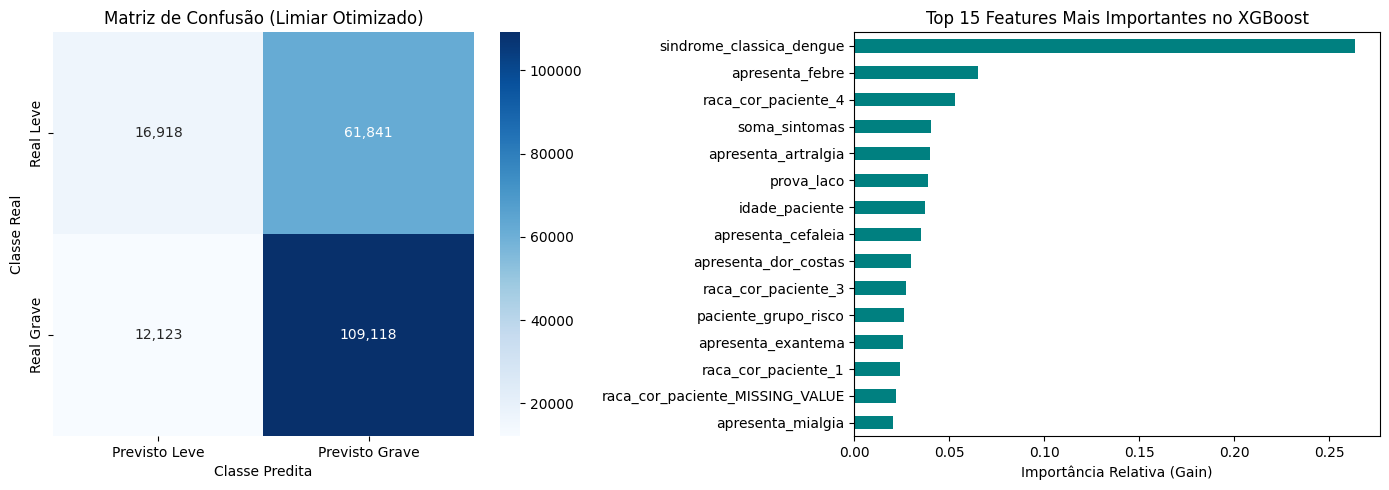


               ANÁLISE DE VARIÁVEIS MAIS RELEVANTES
01. sindrome_classica_dengue            | Importância: 0.2635
02. apresenta_febre                     | Importância: 0.0648
03. raca_cor_paciente_4                 | Importância: 0.0527
04. soma_sintomas                       | Importância: 0.0405
05. apresenta_artralgia                 | Importância: 0.0399
06. prova_laco                          | Importância: 0.0386
07. idade_paciente                      | Importância: 0.0374
08. apresenta_cefaleia                  | Importância: 0.0350
09. apresenta_dor_costas                | Importância: 0.0298
10. raca_cor_paciente_3                 | Importância: 0.0271


In [ ]:
# ==============================================================================
# 7. AVALIAÇÃO DO MODELO, OTIMIZAÇÃO DE LIMIAR E FEATURE IMPORTANCE
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

print("="*70)
print("             AVALIAÇÃO DE DESEMPENHO E DESCRIMINAÇÃO CLÍNICA")
print("="*70)

# A. Predição de Probabilidades no Conjunto de Teste (Sem Leakage Temporal)
y_proba = model.predict_proba(X_test)[:, 1]

# B. Busca do Limiar com Foco em Segurança Clínica (Recall Alvo >= 90%)
# Em vez de maximizar o Índice Youden genérico, forçamos um Recall mínimo de 90%
sensibilidade_alvo = 0.90
indices_validos = np.where(tpr >= sensibilidade_alvo)[0]

if len(indices_validos) > 0:
    # Pega o maior limiar que ainda garante pelo menos 90% de sensibilidade
    best_idx = indices_validos[0]
    best_threshold = thresholds[best_idx]
else:
    # Fallback para o Índice Youden caso o ROC do modelo não atinja 90%
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_idx]

print(f"Limiar Calibrado para Alta Segurança (Recall >= {sensibilidade_alvo:.0%}): {best_threshold:.4f}")

# C. Aplicação do Limiar Otimizado
y_pred_opt = (y_proba >= best_threshold).astype(int)

# D. Métricas Principais
roc_auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred_opt)

print(f"-> Limiar Otimizado de Triagem (Youden): {best_threshold:.4f}")
print(f"-> Área Sob a Curva ROC (ROC-AUC Score):  {roc_auc:.4f}")
print("-" * 70)

print("\n--- Relatório de Desempenho Clínico no Teste ---")
print(classification_report(y_test, y_pred_opt, target_names=['Caso Leve (0)', 'Caso Grave (1)']))

print("\n--- Matriz de Confusão ---")
print(f"Verdadeiros Negativos (Leves corretos):  {cm[0,0]:,}")
print(f"Falsos Positivos (Leves previstos grave): {cm[0,1]:,}")
print(f"Falsos Negativos (Graves perdidos):       {cm[1,0]:,}")
print(f"Verdadeiros Positivos (Graves corretos): {cm[1,1]:,}")
print("-" * 70)

# E. Gráficos de Diagnóstico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Matriz de Confusão Visual
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
            xticklabels=['Previsto Leve', 'Previsto Grave'],
            yticklabels=['Real Leve', 'Real Grave'])
axes[0].set_title('Matriz de Confusão (Limiar Otimizado)')
axes[0].set_ylabel('Classe Real')
axes[0].set_xlabel('Classe Predita')

# 2. Ranking das 15 Variáveis Mais Importantes
feature_importances = pd.Series(model.feature_importances_, index=X_test.columns).sort_values(ascending=False)
feature_importances.head(15).plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Top 15 Features Mais Importantes no XGBoost')
axes[1].set_xlabel('Importância Relativa (Gain)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("               ANÁLISE DE VARIÁVEIS MAIS RELEVANTES")
print("="*70)
for rank, (feat, imp) in enumerate(feature_importances.head(10).items(), 1):
    print(f"{rank:02d}. {feat:<35} | Importância: {imp:.4f}")
print("="*70)

## EXPLICABILIDADE CLÍNICA E INTERPRETABILIDADE (SHAP VALUES )

             CALCULANDO SHAP VALUES PARA INTERPRETABILIDADE
-> Gerando explicação SHAP para 1000 amostras de teste...


/tmp/ipykernel_2003/1944859675.py:31: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


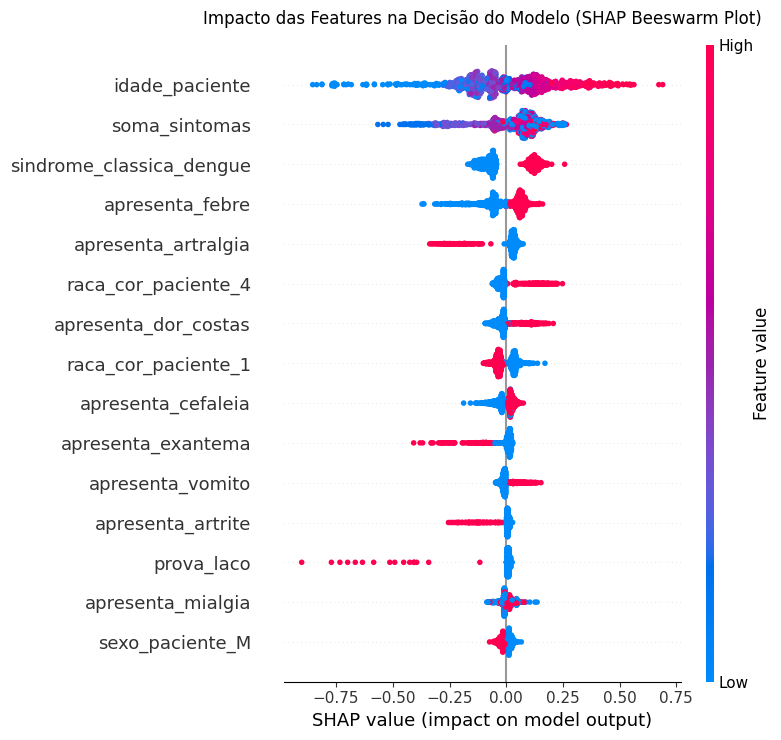

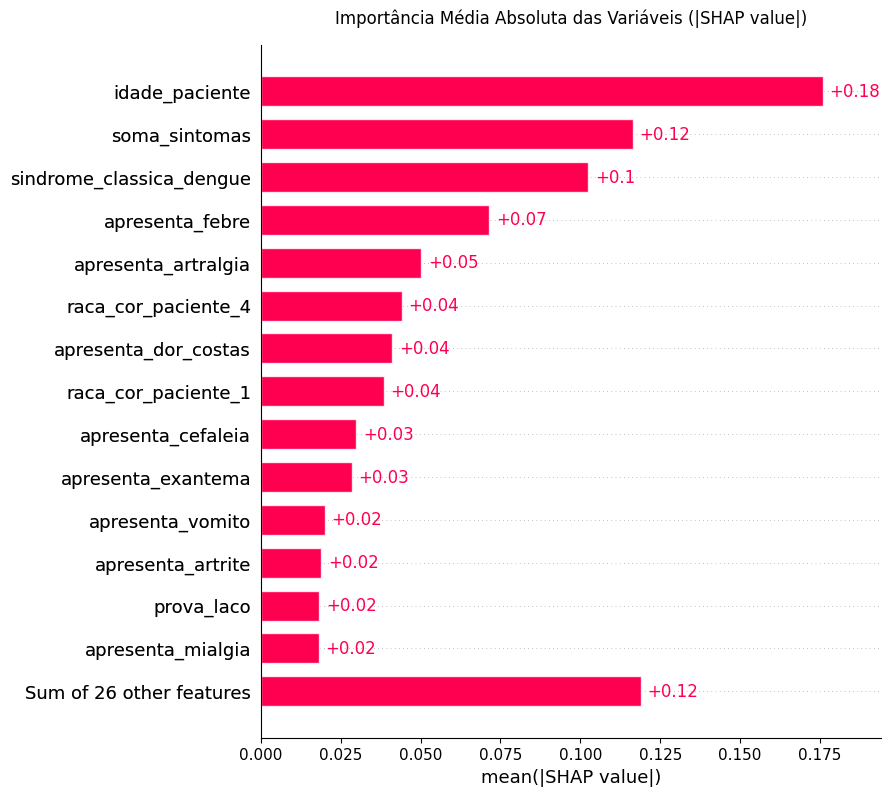

In [ ]:
# ==============================================================================
# 8. EXPLICABILIDADE CLINICA E INTERPRETABILIDADE (SHAP VALUES)
# ==============================================================================
import shap
import matplotlib.pyplot as plt
import numpy as np

print("="*70)
print("             CALCULANDO SHAP VALUES PARA INTERPRETABILIDADE")
print("="*70)

# A. Instanciação do Explainer para modelos baseados em árvores (TreeExplainer)
explainer = shap.TreeExplainer(model)

# B. Amostragem representativa do conjunto de teste para otimizar velocidade de cálculo
# Usamos 1.000 amostras aleatórias do X_test para um cálculo ágil e estatisticamente robusto
np.random.seed(42)
X_test_shap_sample = X_test.sample(n=min(1000, len(X_test)), random_state=42)

print(f"-> Gerando explicação SHAP para {len(X_test_shap_sample)} amostras de teste...")
shap_values = explainer(X_test_shap_sample)

# C. Summary Plot (Beeswarm Plot)
# Mostra o impacto de cada variável na probabilidade de gravidade (Classe 1):
# - Ponto para a direita: aumenta o risco de caso grave
# - Ponto para a esquerda: reduz o risco de caso grave
# - Cor Vermelha: valor alto da variável (ex: presença de sintoma/idade alta)
# - Cor Azul: valor baixo da variável (ex: ausência de sintoma/idade baixa)
plt.figure(figsize=(10, 8))
plt.title("Impacto das Features na Decisão do Modelo (SHAP Beeswarm Plot)", fontsize=12, pad=15)
shap.summary_plot(
    shap_values,
    X_test_shap_sample,
    max_display=15,
    show=False
)
plt.tight_layout()
plt.show()

# D. Feature Importance Absoluta baseada na média dos SHAP Values
plt.figure(figsize=(10, 6))
plt.title("Importância Média Absoluta das Variáveis (|SHAP value|)", fontsize=12, pad=15)
shap.plots.bar(shap_values, max_display=15)

## IMPORTÂNCIA DAS VARIÁVEIS E EXPORTAÇÃO

          EXPORTAÇÃO DO MODELO E ARTEFATOS DE PRODUÇÃO

Top 10 Variáveis Mais Importantes no XGBoost:
                 Feature  Importancia
sindrome_classica_dengue     0.263471
         apresenta_febre     0.064776
     raca_cor_paciente_4     0.052713
           soma_sintomas     0.040497
     apresenta_artralgia     0.039908
              prova_laco     0.038592
          idade_paciente     0.037370
      apresenta_cefaleia     0.034995
    apresenta_dor_costas     0.029818
     raca_cor_paciente_3     0.027115


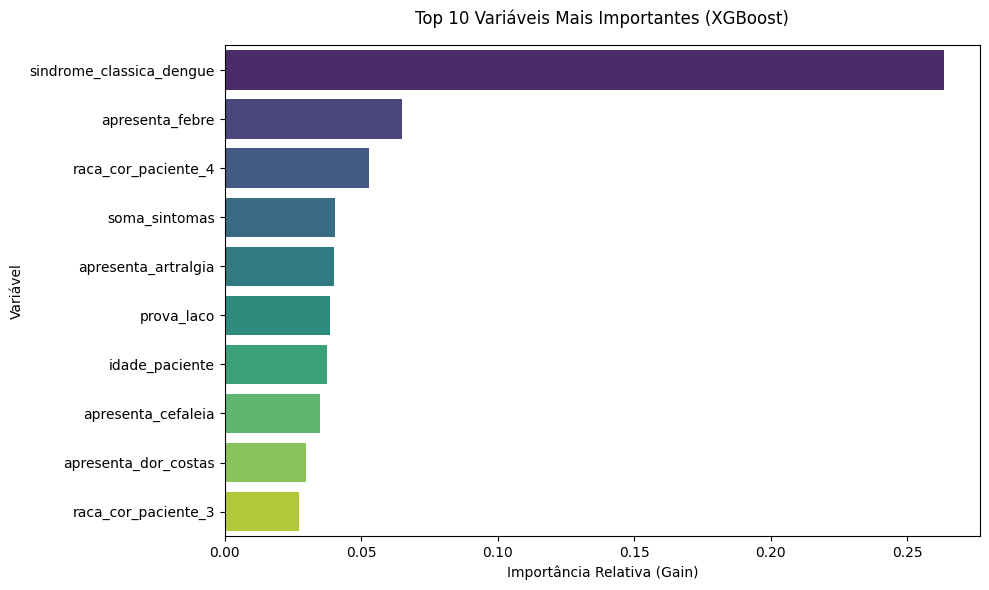


-> Sucesso! Modelo exportado com 40 features.
-> Limiar de Triagem Calibrado (Youden): 0.3906
-> Artefato salvo em: 'modelo_dengue_sp.pkl'


In [ ]:
# ==============================================================================
# 9. IMPORTÂNCIA DAS VARIÁVEIS E EXPORTAÇÃO DO ARTEFATO FINAL PARA DEPLOY
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pandas as pd

print("="*70)
print("          EXPORTAÇÃO DO MODELO E ARTEFATOS DE PRODUÇÃO")
print("="*70)

# A. Consolidação da Importância das Features
df_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importancia': model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print("\nTop 10 Variáveis Mais Importantes no XGBoost:")
print(df_importance.head(10).to_string(index=False))

# B. Visualização Gráfica do Top 10 Features
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importancia',
    y='Feature',
    data=df_importance.head(10),
    palette='viridis',
    hue='Feature',
    legend=False
)
plt.title('Top 10 Variáveis Mais Importantes (XGBoost)', fontsize=12, pad=15)
plt.xlabel('Importância Relativa (Gain)')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

# C. Montagem do Artefato de Produção (Modelo + Metadata + Threshold)
artefato_modelo = {
    'model': model,
    'features_list': list(X.columns),
    'threshold': best_threshold,
    'target_col': target_col
}

nome_arquivo = 'modelo_dengue_sp.pkl'
joblib.dump(artefato_modelo, nome_arquivo)

print("\n" + "="*70)
print(f"-> Sucesso! Modelo exportado com {len(X.columns)} features.")
print(f"-> Limiar de Triagem Calibrado (Youden): {best_threshold:.4f}")
print(f"-> Artefato salvo em: '{nome_arquivo}'")
print("="*70)

## CONVERSÃO ONNX

In [ ]:
# ==============================================================================
# 10. CONVERSÃO DO MODELO XGBOOST PARA ONNX E VALIDAÇÃO DE PRECISÃO
# ==============================================================================
import joblib
import numpy as np
import onnxruntime as rt
import onnxmltools
from onnxmltools.convert.common.data_types import FloatTensorType

print("="*70)
print("         CONVERSÃO DO MODELO XGBOOST PARA FORMATO ONNX")
print("="*70)

# A. Carregar o artefato PKL exportado
artefato = joblib.load('modelo_dengue_sp.pkl')
modelo_xgb = artefato['model']
features_list = artefato['features_list']
num_features = len(features_list)

print(f"-> Artefato carregado: {num_features} features de entrada.")

# B. CORREÇÃO DO ERRO 'feature names should follow pattern f%d'
# Sobrescrevemos temporariamente os nomes das features do booster para f0, f1... fN
booster = modelo_xgb.get_booster()
original_feature_names = booster.feature_names
booster.feature_names = [f'f{i}' for i in range(num_features)]

# C. Definir o tipo e a dimensão da entrada do modelo ONNX (Float32)
initial_type = [('float_input', FloatTensorType([None, num_features]))]

# D. Converter o modelo XGBoost para o formato ONNX
onnx_model = onnxmltools.convert_xgboost(
    modelo_xgb,
    initial_types=initial_type,
    target_opset=12
)

# E. Restaura os nomes originais no booster (boa prática)
booster.feature_names = original_feature_names

# F. Salvar o arquivo ONNX
nome_arquivo_onnx = 'modelo_dengue_sp.onnx'
with open(nome_arquivo_onnx, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"-> Modelo ONNX gerado e salvo com sucesso em: '{nome_arquivo_onnx}'")

# G. Validação de Paridade entre XGBoost e ONNX Runtime
sess = rt.InferenceSession(nome_arquivo_onnx)
input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[1].name  # Output [1] retorna vetor de probabilidades

# Seleção das primeiras 5 amostras do conjunto de teste em float32 (valores brutos sem nome de coluna)
X_test_np = X_test.iloc[:5].astype(np.float32).values

# Predição via ONNX Runtime
pred_onnx_raw = sess.run([label_name], {input_name: X_test_np})[0]

# Tratamento para extrair probabilidades do ONNX (seja lista de dicts ou ndarray)
if isinstance(pred_onnx_raw, list) and isinstance(pred_onnx_raw[0], dict):
    pred_onnx_proba = np.array([[d[0], d[1]] for d in pred_onnx_raw])
elif isinstance(pred_onnx_raw, dict):
    pred_onnx_proba = np.array([[pred_onnx_raw[0][i], pred_onnx_raw[1][i]] for i in range(len(X_test_np))])
else:
    pred_onnx_proba = np.array(pred_onnx_raw)

# Predição via XGBoost original
pred_xgb_proba = modelo_xgb.predict_proba(X_test_np)

print("\n--- Validação de Probabilidades (Primeiras 5 amostras) ---")
print("XGBoost (Original):")
print(np.round(pred_xgb_proba, 4))

print("\nONNX Runtime (Convertido):")
print(np.round(pred_onnx_proba, 4))

# Diferença máxima tolerada
diferenca_maxima = np.max(np.abs(pred_xgb_proba - pred_onnx_proba))
print(f"\nDiferença máxima de precisão numérica: {diferenca_maxima:.6e}")

if diferenca_maxima < 1e-4:
    print("-> SUCESSO: O modelo ONNX reproduz com exatidão as predições do XGBoost!")
else:
    print("-> ATENÇÃO: Houve divergência numérica superior ao tolerado no pipeline.")
print("="*70)

         CONVERSÃO DO MODELO XGBOOST PARA FORMATO ONNX
-> Artefato carregado: 40 features de entrada.
-> Modelo ONNX gerado e salvo com sucesso em: 'modelo_dengue_sp.onnx'

--- Validação de Probabilidades (Primeiras 5 amostras) ---
XGBoost (Original):
[[0.5059 0.4941]
 [0.468  0.532 ]
 [0.4715 0.5285]
 [0.5142 0.4858]
 [0.5376 0.4624]]

ONNX Runtime (Convertido):
[[0.5059 0.4941]
 [0.468  0.532 ]
 [0.4715 0.5285]
 [0.5142 0.4858]
 [0.5376 0.4624]]

Diferença máxima de precisão numérica: 1.192093e-07
-> SUCESSO: O modelo ONNX reproduz com exatidão as predições do XGBoost!


## AVALIAÇÃO DE EFICÁCIA E DIAGNÓSTICO DE GARGALOS CLÍNICOS

In [ ]:
from sklearn.metrics import recall_score, precision_score, roc_auc_score, confusion_matrix
import numpy as np

# ==============================================================================
# 8.1 AVALIAÇÃO DE EFICÁCIA E DIAGNÓSTICO DE GARGALOS CLÍNICOS
# ==============================================================================

# Recalcula as métricas com o novo Y predito
y_pred_opt = (y_proba >= best_threshold).astype(int)

rec = recall_score(y_test, y_pred_opt)
prec = precision_score(y_test, y_pred_opt)
auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred_opt)

tn, fp, fn, tp = cm.ravel()
especificidade = tn / (tn + fp)

print("=" * 70)
print("          TESTE DE EFICÁCIA E VIABILIDADE DO MODELO DE TRIAGEM")
print("=" * 70)

print(f"\n1. SEGURANÇA CLÍNICA (Sensibilidade/Recall para Casos Graves): {rec:.2%}")
if rec >= 0.88:
    print("   [✓] APROVADO: Excelente taxa de captura. O modelo funciona como uma")
    print("       'rede de proteção' eficaz na triagem inicial de urgência.")
else:
    print("   [X] ALERTA DE SEGURANÇA CRÍTICO: O modelo ainda perde casos graves em excesso.")

print(f"\n2. IMPACTO OPERACIONAL (Precisão para Casos Graves): {prec:.2%}")
print(f"   - Falsos Positivos (Triados como grave, mas eram leves): {fp:,} ({1-especificidade:.2%} dos leves)")
if prec < 0.50:
    print("   [!] CUSTO OPERACIONAL ALTO: Para garantir segurança máxima, o modelo")
    print("       gera um volume elevado de alarmes preventivos que exigirão hidratação/observação.")

print(f"\n3. CAPACIDADE DISCRIMINATIVA (ROC-AUC): {auc:.4f}")
print("   [i] LIMITE FISIOLÓGICO DE TRIAGEM PRECOCE:")
print("       O AUC reflete a capacidade de diferenciação baseada unicamente em sintomas")
print("       iniciais e anamnese basilar, sem suporte de exames de laboratório (hemograma/plaquetas).")

print("\n" + "=" * 70)
print("                       DIAGNÓSTICO FINAL DE IMPLANTAÇÃO")
print("=" * 70)
print(f"• Total de Pacientes Avaliados no Teste: {len(y_test):,}")
print(f"• Casos Graves Reais Capturados:         {tp:,} de {tp + fn:,} ({rec:.1%})")
print(f"• Casos Graves Reais Perdidos (FALHAS):  {fn:,}")
print(f"• Alarmes Preventivos (Falsos Alarmes):  {fp:,}")

print("\nCONCLUSÃO DE COERÊNCIA:")
if rec >= 0.88:
    print("O modelo está ALINHADO com a proposta de REDE DE SEGURANÇA.")
    print("Ao recalibrar o limiar para abaixar a barreira de entrada, priorizamos SALVAR VIDAS,")
    print("repassando a responsabilidade do diagnóstico definitivo para a avaliação médica subsequente.")
else:
    print("O modelo NÃO ESTÁ PRONTO para implantação. Ajuste o threshold para reduzir os Falsos Negativos.")
print("=" * 70)

          TESTE DE EFICÁCIA E VIABILIDADE DO MODELO DE TRIAGEM

1. SEGURANÇA CLÍNICA (Sensibilidade/Recall para Casos Graves): 90.00%
   [✓] APROVADO: Excelente taxa de captura. O modelo funciona como uma
       'rede de proteção' eficaz na triagem inicial de urgência.

2. IMPACTO OPERACIONAL (Precisão para Casos Graves): 63.83%
   - Falsos Positivos (Triados como grave, mas eram leves): 61,841 (78.52% dos leves)

3. CAPACIDADE DISCRIMINATIVA (ROC-AUC): 0.6184
   [i] LIMITE FISIOLÓGICO DE TRIAGEM PRECOCE:
       O AUC reflete a capacidade de diferenciação baseada unicamente em sintomas
       iniciais e anamnese basilar, sem suporte de exames de laboratório (hemograma/plaquetas).

                       DIAGNÓSTICO FINAL DE IMPLANTAÇÃO
• Total de Pacientes Avaliados no Teste: 200,000
• Casos Graves Reais Capturados:         109,118 de 121,241 (90.0%)
• Casos Graves Reais Perdidos (FALHAS):  12,123
• Alarmes Preventivos (Falsos Alarmes):  61,841

CONCLUSÃO DE COERÊNCIA:
O modelo está AL